In [150]:
import numpy as np
from numpy.random import default_rng
from scipy.stats import norm, truncnorm

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Text

**Descrizione:**

Lo scopo è effettuare, mediante una simulazione Monte Carlo, un’analisi di impatto relativa alle
incertezze di un modello newsvendor. Assumiamo una distribuzione normale della domanda, per la
quale è facile non solo trovare la soluzione ottima, ma anche il profitto atteso data una quantità
ordinata.

I fattori di incertezza sono i parametri della distribuzione di probabilità (che vengono stimati sulla
base di un campione limitato di domanda) ed il prezzo scontato dopo la finestra di vendita (che
potremmo dovere abbassare per ragioni varie). Errori di stima portano a scegliere una quantità
ordinata non ottimale in realtà.

Le incertezze hanno un impatto misurabile in termini di rapporto tra il profitto effettivamente ottenuto
e quello teoricamente ottimo (in valore atteso). Sarebbe preferibile produrre grafici che mostrano la
degradazione del risultato al variare di fattori di contesto e parametri incerti.

**Esempi di questioni:**
- Che impatto ha la dimensione del campione sulla base del quale si stimano i parametri della distribuzione normale?
- Che impatto ha l’errore di previsione sul prezzo di svendita che si riesce effettivamente ad applicare?
- Che impatto ha il rapporto tra i costi di underage e overage?
- Che impatto ha il rapporto tra deviazione standard e valore atteso (**NB**: evitare casi in cui la probabilità di domanda negativa non è trascurabile)?

# Mathematical Background

**Newsvendor setting**

- $q$: quantity of items to buy
- $c$ : unit cost
- $D$ : demand such that $D \sim Norm(\mu, \sigma)$. We call $d$ the realizaton of $D$, i.e. we say $d$ when we suppose to work with the actual number, rather than the random variable $D$
- $p$ : unit price of the item. Obviously, $p > c$
- $r$ : salvage value, i.e. how much we earn for unsold items (a sort of discount price). It must be $r < c$ to ensure overage actually costs money to us
- $c_u = p - c$ : cost of underage, i.e. the loss we occur everytime we are not able to satisfy the demand of one item. It is the lost profit per unit from unmet demand. Obviously, it can also be seen as the unit profit margin.
- $c_o = c - r$ : cost of overage, i.e. the loss per unit of excess inventory 
- $\pi(q, d)$ : profit. Since the demand is a random variable, it is defined as $$ \pi(q, d) = c_u \cdot \min(q, d) - c_o \cdot \max(q-d, 0)$$
- $q^\ast$ : quantity to buy in order to maximise the expected profit "$E[\pi(q, D)]$"

---

**When $D \sim Norm(\mu, \sigma)$**:

In addition to what we is written above:
$$
\begin{cases}
    q^\ast = \mu + \sigma \cdot z(\frac{c_u}{c_u + c_o})\\
    \\
    E[\pi(q, D)] = c_o \cdot \mu - c_o\cdot (q-\mu) - (c_u + c_o)\cdot \sigma \cdot L\left(\frac{q-\mu}{\sigma}\right) \\
    \\
    L(z) = \phi(z) - z\cdot \left(1 - \Phi(z) \right), & \phi=pdf, \; \Phi = cdf
\end{cases}
$$


---

**PROBLEM:**

Okay, we know that the demand is normally distributed $$D\sim Norm(\mu, \sigma)$$ Then, the problem is solved simply knowing $\mu$ and $\sigma$. However, we do **not** know what their real values are. Indeed, we are only able to retrieve an estimate based on a sample:
$$
sample \longrightarrow \hat{\mu}, \hat{\sigma} \implies \hat{q^\ast} = \hat{\mu} + \hat{\sigma} \cdot z(\frac{c_u}{c_u + c_o})
$$
This obviously implies that, by using $\hat{q}^\ast$, the expected profit "$E[\pi(q, D)]$" calculated based on this number will be **lower** than the one taking the **true** optimal value $q^\ast$.

Thus the questions are quite straightforward:
1. **How many money do we loose considering $\hat{q}^\ast$ instead of $q^\ast$? I.e. how "$E[\pi(q, D)]$" changes** 
2. **In addition to the previous question, how this loss changes by changing $c_u$ and $c_o$?**

Clearly, the main player is
- _sample size_ : the higher the sample size, the nearest will $\hat{\mu}$ and $\hat{\sigma}$ be w.r.t. $\mu$ and $\sigma$ $\implies$ the nearest will $\hat{q}^\ast$ be w.r.t. $q^\ast$ 

---

**IDEA**


# CODE

## Functions

In [151]:
#FUNCTIONS: 

def unit_costs(c: float, p: float, r: float) -> tuple:
    """
    Compute unit costs, level of service and quantile

    Args:
        c (float): unit cost, dollars
        p (float): unit price, dollars
        r (float): salvage value

    Returns:
        c_u, c_o, los (tuple): u.c. of underage, u.c. of overage, level of service and quantile
    """
    c_u = p - c #unit cost of underage
    c_o = c - r #unit cost of overage
    los = c_u / (c_u + c_o) #level of service
    return c_u, c_o, los


def compute_qopt(mu:float, sigma: float, los: float) -> float | np.ndarray:
    """
    Compute the optimal order quantity q* = mu + sigma * z(los) to maximise Expected Profit.
    Accepts scalars (when computing exact q*) or NumPy arrays (in Monte Carlo context ) for mu and sigma 

    Args:
        mu (scalar or array): mean
        sigma (scalar or array): standard deviation
        los (float): level of service , c_u / (c_u + c_o)

    Returns:
        q_opt (float or array): optimal quantity q* or q^, depending on mu and sigma 
    """
    quantile_std = norm.ppf(los) # z(c_u / (c_u + c_o))
    q_opt = mu + sigma*quantile_std #q* or q^, i.e. the quantity that maximise the expected profit, based on the input provided
    return q_opt

def compute_ExpectedProfit(q:float, mu: float, sigma: float, c_u: float, c_o: float) -> float | np.ndarray:
    """
    Compute the true expected profit for a given quantity q.

    Accepts scalars (when computing exact E[profit] ) or NumPy arrays (in Monte Carlo context ) for q, mu and sigma

    Args:
        q (scalar or array): quantity
        mu (scalar or array): mean
        sigma (scalar or array): std
        c_u (float): u.c. of underage
        c_o (float): u.c. of overage

    Returns:
        E_profit (float): Expected Profit
    """
    inp = (q-mu)/sigma #constant val, only compute once for computational efficiency
    loss_func = norm.pdf(inp) - (inp) * (1 - norm.cdf(inp)) # loss function L

    E_profit = c_u * mu - c_o * (q-mu) - (c_u + c_o) * sigma * loss_func # expected profit
    return E_profit


def generate_scenarios(n_sample:int, n_scenarios:int, mu_true: float, sigma_true:float, rng) -> tuple[np.ndarray, np.ndarray]:
    """
    Perform Monte Carlo simulation, generating n_scenarios demand scenarios, each one having n_sample demand data points

    Args:
        n_sample (int): number of demanda data points for each scenario
        n_scenarios (int): number of scenarios
        mu_true (float): population mean
        sigma_true (float): populations std
        rng : random number generator

    Returns:
        mu_array: array of sample means, one for each scenario
        sigma_array: array of sample stds, one for each scenario
    """
    # array fulfilled with scenarios. Vectorize for computational efficiency
    scenarios_array = rng.normal(loc=mu_true, scale=sigma_true, size=(n_scenarios, n_sample))

    mu_array = np.mean(scenarios_array, axis=1) # array of sample means, one for each scenario
    sigma_array = np.std(scenarios_array, ddof=1, axis=1) #array of sample stds, one for each scenario

    return mu_array, sigma_array


def compute_EPratio(E_profit: float, ep_hats: np.ndarray) -> np.ndarray:
    """
    Compute the ratios between the Expected Profit of one scenario (i.e. considering q_hat, suboptimal) and the one computed with "q^*", the optimal quantity.

    Args:
        E_profit (float): True Expected Profit, i.e. computed with q*
        ep_hats (np.ndarray): Array of expected profits. Each entry is estimated based on q hat

    Returns:
        ep_ratios (np.ndarray): ratios E[profit(q_hat, D)] / E[profit(q*, D)]
    """
    ep_ratios = ep_hats/E_profit
    return ep_ratios

In [152]:
# Reproducibility
SEED = 357948
rng = default_rng(SEED)

# Initialize Economics
c = 60 #unit cost, dollars
p = 100 #unit price, dollars
r = 45 # salvage value

# Initialize distribution parameters
mu_true = 1000 # average demand
sigma_true = 150 # standard deviation


#Monte Carlo simulation parameters
n_samples = np.array([2, 5, 10, 20, 30, 50, 200, 500, 1000]) #demand data points
n_scenarios = 10_000 # number of scenarios
alpha = 0.95 #confidence level
#---

#ASSUMPTIONS
assumptions = "ASSUMPTIONS"
print("="*100)
print(f"{assumptions:^100}")
print("="*100)
print("")
print(f"{'- The product can be bought in fractions, therefore q is a positive float':<10}")

                                            ASSUMPTIONS                                             

- The product can be bought in fractions, therefore q is a positive float


## Q1

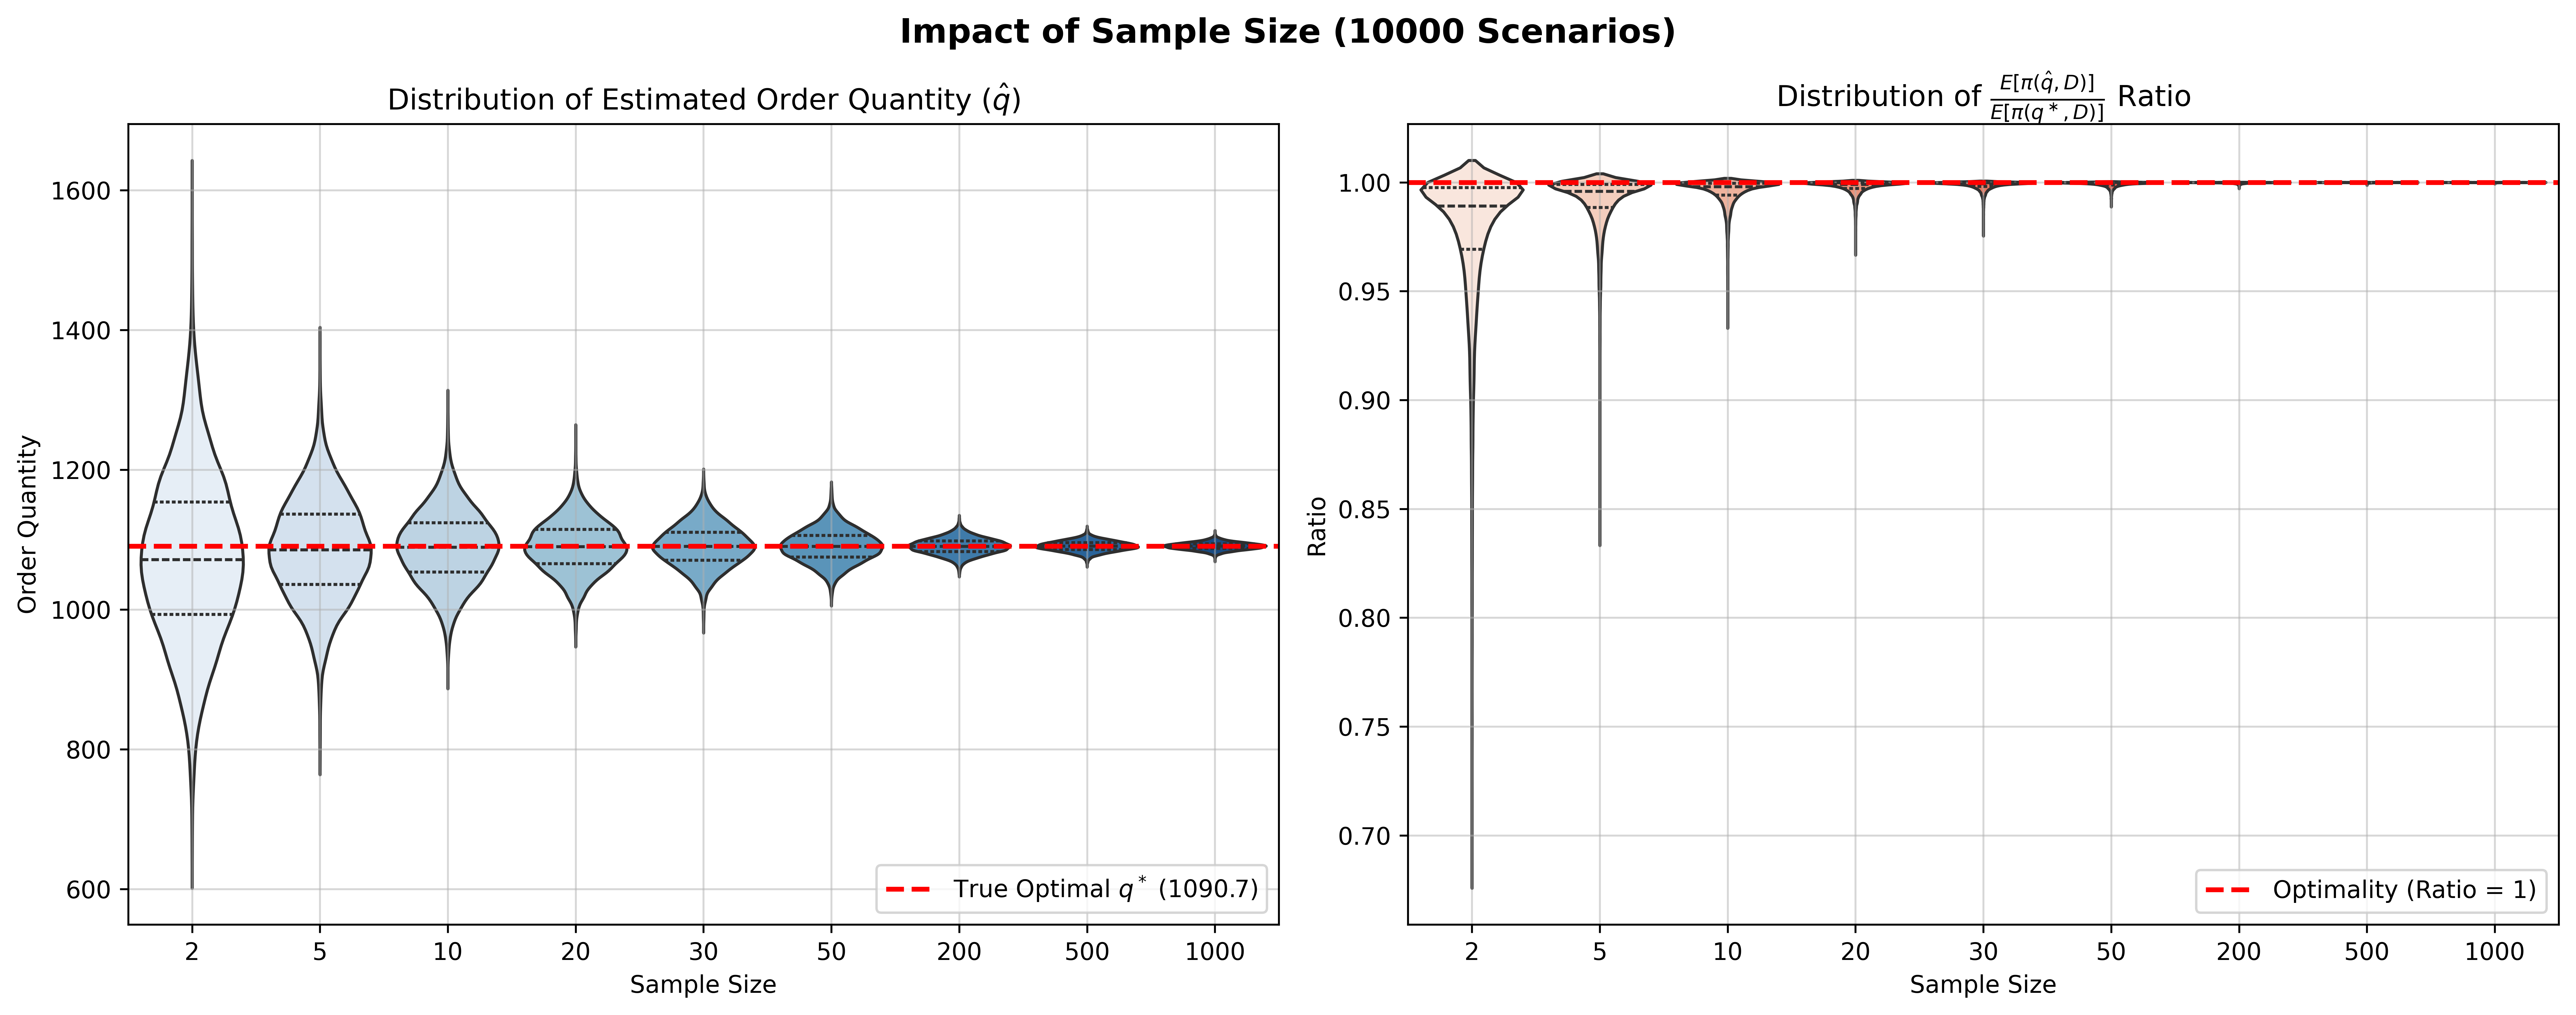

In [153]:
# =======================================================================================
# Q1 - How the sample dimension affects the ratio E[profit(q^, D)]/E[profit(q*, D)]     
# =======================================================================================

# === Calculations

#Compute missing economics
c_u, c_o, los = unit_costs(c=c, p=p, r=r)

#Compute exact values
q_opt = compute_qopt(mu=mu_true, sigma=sigma_true, los=los)
ep_opt = compute_ExpectedProfit(q=q_opt, mu=mu_true, sigma=sigma_true, c_u=c_u, c_o=c_o)

#simulation
ratios = {}  # store n_sample -> ep_ratios array
q_suboptimals = {} #store n_sample -> q_hats
for n in n_samples:
    mu_array, sigma_array = generate_scenarios(n_sample=n, n_scenarios=n_scenarios, mu_true=mu_true, sigma_true=sigma_true, rng=rng) 

    # compute q^, E[profit(q^, D)] and the ratio E[profit(q^, D)]/E[profit(q*, D)]
    q_hats = compute_qopt(mu=mu_array, sigma=sigma_array, los=los) # shape(n_scenarios, )
    ep_hats = compute_ExpectedProfit(q=q_hats, mu=mu_true, sigma=sigma_true, c_u=c_u, c_o=c_o)
    ep_ratios = compute_EPratio(E_profit=ep_opt, ep_hats=ep_hats)

    # store results
    ratios[n] = ep_ratios
    q_suboptimals[n] = q_hats

#dfs to better handle visualizations
df_ratios=pd.DataFrame(ratios)
df_qsub = pd.DataFrame(q_suboptimals)

# === RESULTS

# PLOTS
fig, ax = plt.subplots(1,2, figsize=(15, 6), dpi=600)
fig.suptitle(f"Impact of Sample Size ({n_scenarios} Scenarios)", fontsize=14, y=0.97, fontweight="bold")

# boxplot 1 - q^ distribution
sns.violinplot(
    data=df_qsub,
    inner="quartile",
    ax=ax[0],
    fill=True,
    palette="Blues"
)
ax[0].axhline(y=q_opt, color='red', linestyle='--', linewidth=2, label=f'True Optimal $q^*$ ({q_opt:.1f})')

ax[0].set_title("Distribution of Estimated Order Quantity ($\hat{q}$)", fontsize=12)
ax[0].set_xlabel("Sample Size")
ax[0].set_ylabel("Order Quantity")
ax[0].legend(loc="lower right")
ax[0].grid(True, alpha=0.5)

#boxplot 2 - Ratio distribution for each Sample Size
sns.violinplot(
    data=df_ratios,
    inner="quartile",
    ax=ax[1],
    palette="Reds",
    fill=True
)
ax[1].axhline(y=1.0, color='red', linestyle='--', linewidth=2, label=f'Optimality (Ratio = 1)')

ax[1].set_title(rf"Distribution of $\frac{{E[\pi(\hat{{q}}, D)]}}{{E[\pi(q^\ast, D)]}}$ Ratio", fontsize=12)
ax[1].set_xlabel("Sample Size")
ax[1].set_ylabel("Ratio")
ax[1].legend(loc="lower right")
ax[1].grid(True, alpha=0.5)


plt.tight_layout()
plt.show()

#save image in HIGH quality
fig.savefig("q1ViolinPlots.pdf", bbox_inches="tight")

In [154]:
# === SUMMARY STATISTICS - Q1
print("\n" + "="*80)
print(f"{'Q1 - SUMMARY STATISTICS: Impact of Sample Size on Ratio Distribution':^80}")
print("="*80)

ci_level = alpha * 100
lower_q = (1 - alpha) / 2
upper_q = 1 - lower_q

summary_rows = [] #store results
for n in n_samples:
    rat = ratios[n]
    summary_rows.append({
        "n_sample":       n,
        "mean":           np.mean(rat),
        "std":            np.std(rat),
        "median":         np.median(rat),
        f"q{(round(lower_q*100, 1))}":  np.quantile(rat, lower_q),
        f"q{(round(upper_q*100, 1))}":  np.quantile(rat, upper_q),
        f"CI_{ci_level}%_width": np.quantile(rat, upper_q) - np.quantile(rat, lower_q),
        "pct_above_1":    100 * np.mean(rat > 1),
    })

df_summary_q1 = pd.DataFrame(summary_rows).set_index("n_sample")
print(df_summary_q1.to_string(float_format="{:.4f}".format))


      Q1 - SUMMARY STATISTICS: Impact of Sample Size on Ratio Distribution      
           mean    std  median   q2.5  q97.5  CI_95.0%_width  pct_above_1
n_sample                                                                 
2        0.9770 0.0319  0.9892 0.8869 1.0000          0.1130       0.0000
5        0.9913 0.0126  0.9959 0.9561 1.0000          0.0439       0.0000
10       0.9957 0.0060  0.9980 0.9784 1.0000          0.0215       0.0000
20       0.9978 0.0031  0.9990 0.9890 1.0000          0.0110       0.0000
30       0.9986 0.0020  0.9994 0.9931 1.0000          0.0069       0.0000
50       0.9991 0.0012  0.9996 0.9957 1.0000          0.0043       0.0000
200      0.9998 0.0003  0.9999 0.9989 1.0000          0.0011       0.0000
500      0.9999 0.0001  1.0000 0.9996 1.0000          0.0004       0.0000
1000     1.0000 0.0001  1.0000 0.9998 1.0000          0.0002       0.0000


In [155]:
round(ep_opt, 1), round(q_opt, 1)
print("="*100)
print(f"{'EXACT THEORETICAL VALUES':^100}")
print("="*100)
print("")
print(f"{'- Optimal Order Quantity (q*):':<35} {q_opt:.1f} units")
print(f"{'- Maximum Expected Profit:':<35} ${ep_opt:.1f}")
print("\n")

                                      EXACT THEORETICAL VALUES                                      

- Optimal Order Quantity (q*):      1090.7 units
- Maximum Expected Profit:          $37258.5




## Q2



**IDEA**: The salvage price $r$ affects the unit cost of overage $c_o = c-r$, which indeed affects the ordered quantity $q$. If the know in advance what the salvage price we are fine, however due to whatever reason we may not know exactly $r \implies$ we have to place the order $q$ with $r_{est}$. The goal now is to understand how the estimate for $r$ affects this choice, we study 2 scenarios:

- r $\sim$ truncnorm scenario analyses the market noise: we have to place the order at time T, however the unsold items will be sold at time T+t at price r. During this interval things changes, therefore, we estimate to able to sell at a certain price however at T+t we will be able to sell at r = 45. Thus, this simulates the market noise

- r $\sim$ betas scenario analyses the impact of under/overestimation more on the "human being" side, and it can be worth as well to see how this impacts

(More refined :)

- The Truncnorm (Market Noise): This models the unavoidable temporal uncertainty. We lock in our order $\hat{q}$ at time $T$, but the actual salvage liquidation happens at $T+t$. The truncnorm perfectly simulates random, symmetric market drift during that interval, assuming our initial estimate was theoretically sound.
- The Betas (Human/Institutional Bias): This models internal operational risk. It answers what happens when the team making the decisions at time $T$ is structurally overconfident (Optimistic) or overly risk-averse (Pessimistic).

_OUTPUT_:
- violin plots

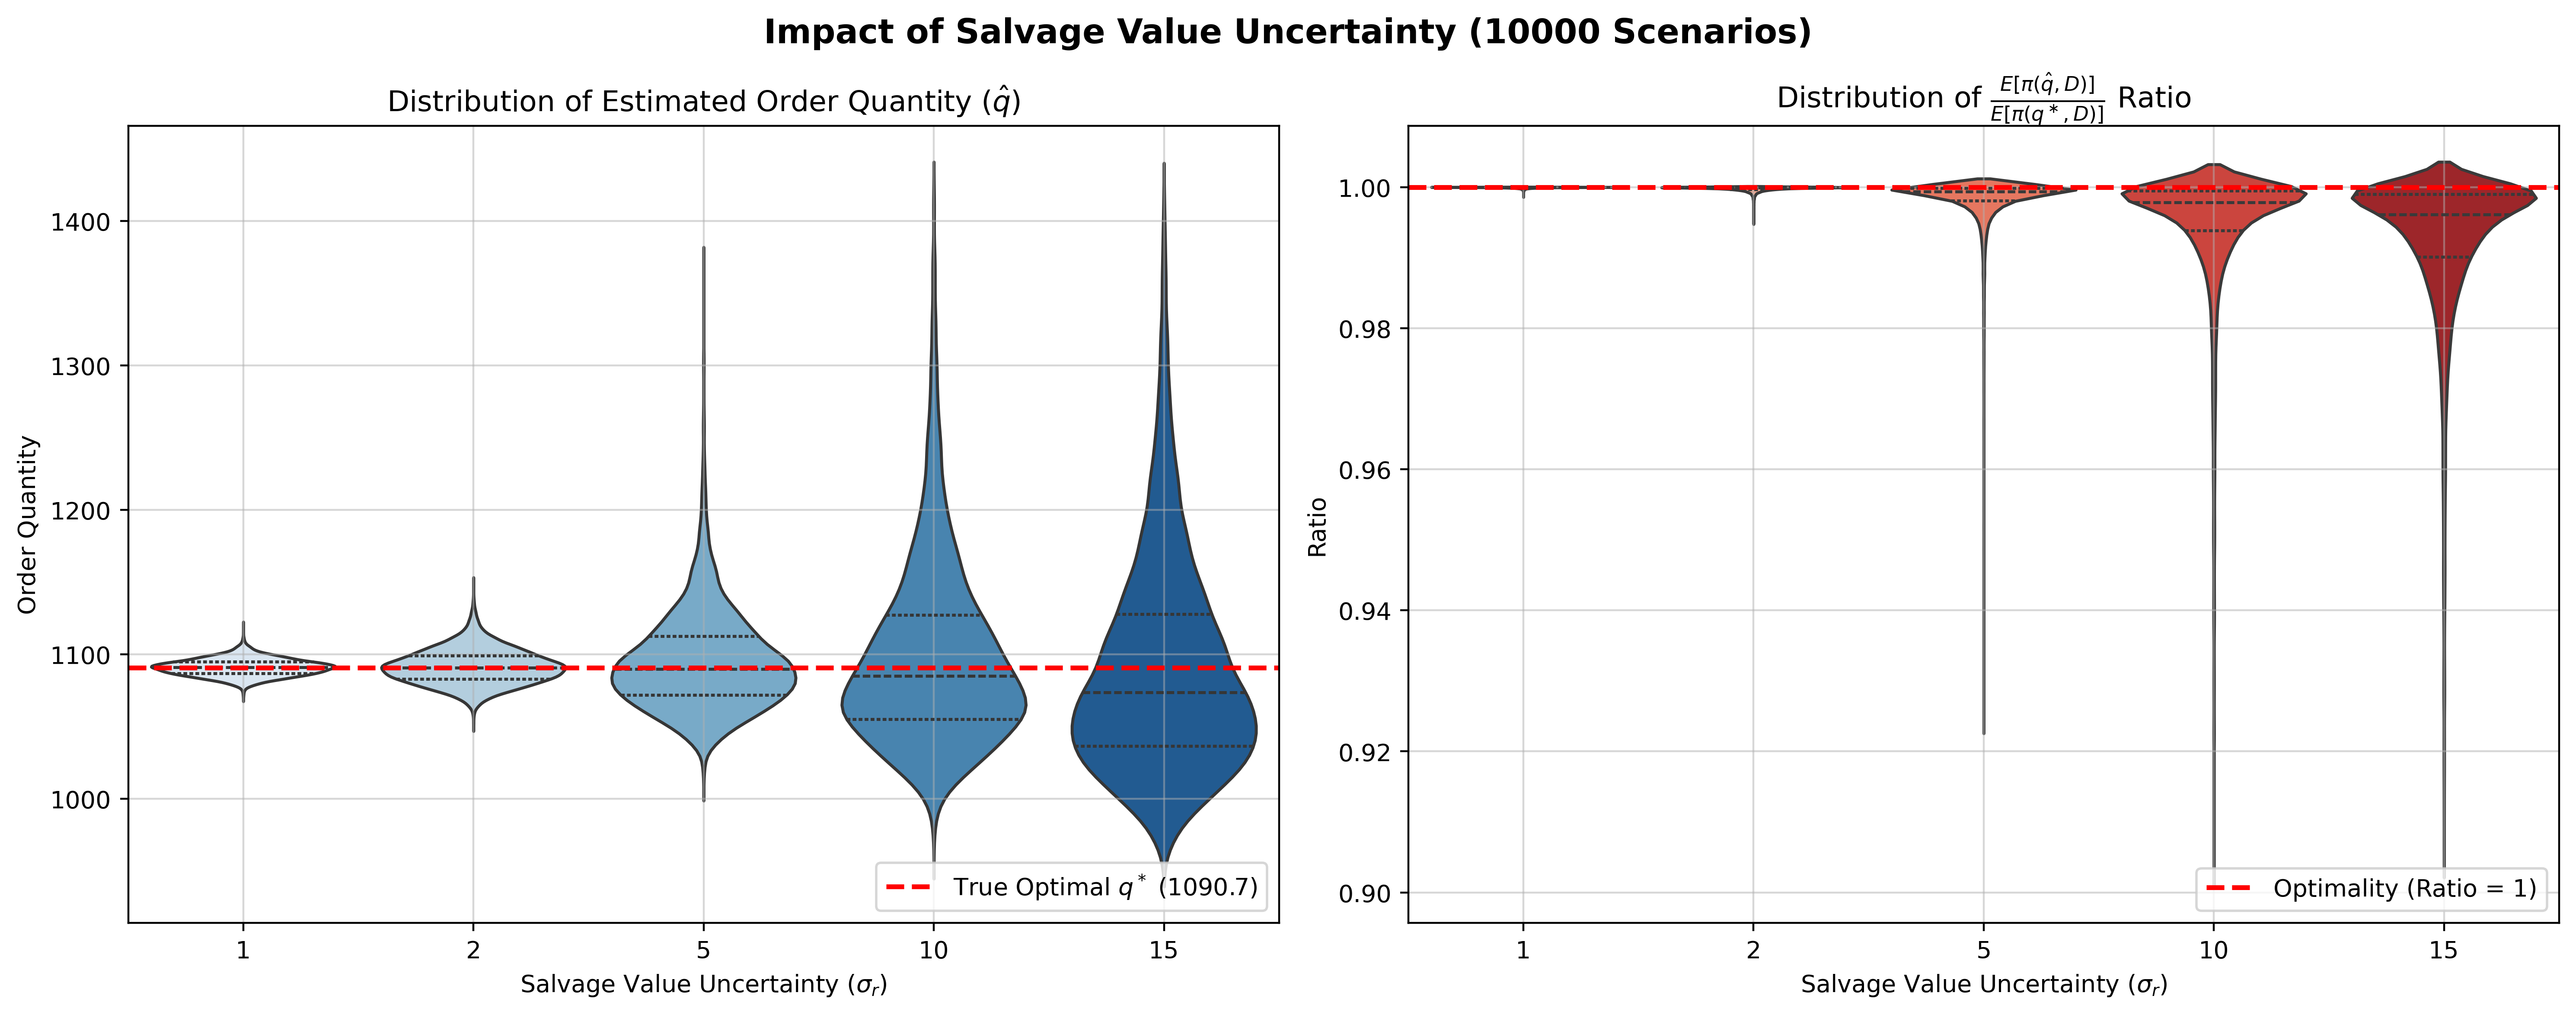

In [156]:
# =============================================================================================
# Q2 - How the salvage price estimate error affects the ratio E[profit(q^, D)]/E[profit(q*, D)]     
# =============================================================================================
#update economics
r_true = r 
co_true = c- r_true

# === TRUNCATED NORM ASSUMPTION: r \sim TruncNorm

#truncnorm parameters
r_std = np.array([1, 2, 5, 10, 15]) #std, uncertainty on r
a_trunc = 0 #abscissa left limit, since it must be r >= 0
b_trunc = c-0.1 #abscissa right limit, since it must be r<c

#store results
store_rhats_truncnorm = {} #store the r drawned for different std
q_suboptimals_runc_truncnorm = {} #store n_sample -> q_hats
ratios_runc_truncnorm = {}  # store n_sample -> ep_ratios array

for std in r_std:
    a, b = (a_trunc - r_true) / std, (b_trunc - r_true) / std #truncnorm does not receive the plain limits as input, see docs for more info
    r_hats_tn = truncnorm.rvs(a, b, loc=r_true, scale=std, size=n_scenarios, random_state=rng) # one r for each demand scenario
    co_hats_tn = c - r_hats_tn 
    los_hats_tn = c_u/(c_u + co_hats_tn)
    q_hats_tn = compute_qopt(mu=mu_true, sigma=sigma_true, los=los_hats_tn)
    ep_hats_tn = compute_ExpectedProfit(q=q_hats_tn, mu=mu_true, sigma=sigma_true, c_u=c_u, c_o=co_true)
    ep_ratios_tn = compute_EPratio(E_profit=ep_opt, ep_hats=ep_hats_tn)

    #append results
    store_rhats_truncnorm[std] = r_hats_tn
    q_suboptimals_runc_truncnorm[std] =  q_hats_tn
    ratios_runc_truncnorm[std] = ep_ratios_tn 

#dfs to better handle visualizations
df_rhats_truncnorm = pd.DataFrame(store_rhats_truncnorm)
df_qsub_runc_truncnorm = pd.DataFrame(q_suboptimals_runc_truncnorm)
df_ratios_runc_truncnorm = pd.DataFrame(ratios_runc_truncnorm)

# === RESULTS

# PLOTS
fig, ax = plt.subplots(1, 2, figsize=(15, 6), dpi=400)
fig.suptitle(f"Impact of Salvage Value Uncertainty ({n_scenarios} Scenarios)", fontsize=14, y=0.97, fontweight="bold")

# boxplot 1 - q^ distribution
sns.violinplot(
    data=df_qsub_runc_truncnorm,
    inner="quartile",
    ax=ax[0],
    fill=True,
    palette="Blues"
)
ax[0].axhline(y=q_opt, color='red', linestyle='--', linewidth=2, label=f'True Optimal $q^*$ ({q_opt:.1f})')

ax[0].set_title("Distribution of Estimated Order Quantity ($\hat{q}$)", fontsize=12)
ax[0].set_xlabel("Salvage Value Uncertainty ($\sigma_r$)")
ax[0].set_ylabel("Order Quantity")
ax[0].legend(loc="lower right")
ax[0].grid(True, alpha=0.5)

# boxplot 2 - Ratio distribution for each Uncertainty Level
sns.violinplot(
    data=df_ratios_runc_truncnorm,
    inner="quartile",
    ax=ax[1],
    palette="Reds",
    fill=True
)
ax[1].axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Optimality (Ratio = 1)')

ax[1].set_title(rf"Distribution of $\frac{{E[\pi(\hat{{q}}, D)]}}{{E[\pi(q^\ast, D)]}}$ Ratio", fontsize=12)
ax[1].set_xlabel("Salvage Value Uncertainty ($\sigma_r$)")
ax[1].set_ylabel("Ratio")
ax[1].legend(loc="lower right")
ax[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

#save image in HIGH quality
fig.savefig("q2ViolinPlots.pdf", bbox_inches="tight")

In [157]:
# === SUMMARY STATISTICS - Q2
print("\n" + "="*80)
print(f"{'Q2 - SUMMARY STATISTICS: Impact of Salvage Value Uncertainty':^80}")
print("="*80)

summary_rows = []
for std in r_std:
    rat2 = ratios_runc_truncnorm[std]
    summary_rows.append({
        "sigma_r":        std,
        "mean":           np.mean(rat2),
        "std":            np.std(rat2),
        "median":         np.median(rat2),
        f"q{(round(lower_q*100, 1))}":  np.quantile(rat2, lower_q),
        f"q{(round(upper_q*100, 1))}":  np.quantile(rat2, upper_q),
        f"CI_{ci_level}%_width": np.quantile(rat2, upper_q) - np.quantile(rat2, lower_q),
        "pct_above_1":    100 * np.mean(rat2 > 1),
    })

df_summary_q2 = pd.DataFrame(summary_rows).set_index("sigma_r")
print(df_summary_q2.to_string(float_format="{:.4f}".format))


          Q2 - SUMMARY STATISTICS: Impact of Salvage Value Uncertainty          
          mean    std  median   q2.5  q97.5  CI_95.0%_width  pct_above_1
sigma_r                                                                 
1       0.9999 0.0001  1.0000 0.9997 1.0000          0.0003       0.0000
2       0.9998 0.0004  0.9999 0.9988 1.0000          0.0012       0.0000
5       0.9982 0.0038  0.9993 0.9892 1.0000          0.0108       0.0000
10      0.9944 0.0102  0.9979 0.9629 1.0000          0.0371       0.0000
15      0.9922 0.0113  0.9961 0.9589 1.0000          0.0410       0.0000


## Q3

/var/folders/48/rr_ylfv12t3fb01_brwwlvh00000gn/T/ipykernel_2439/609240161.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


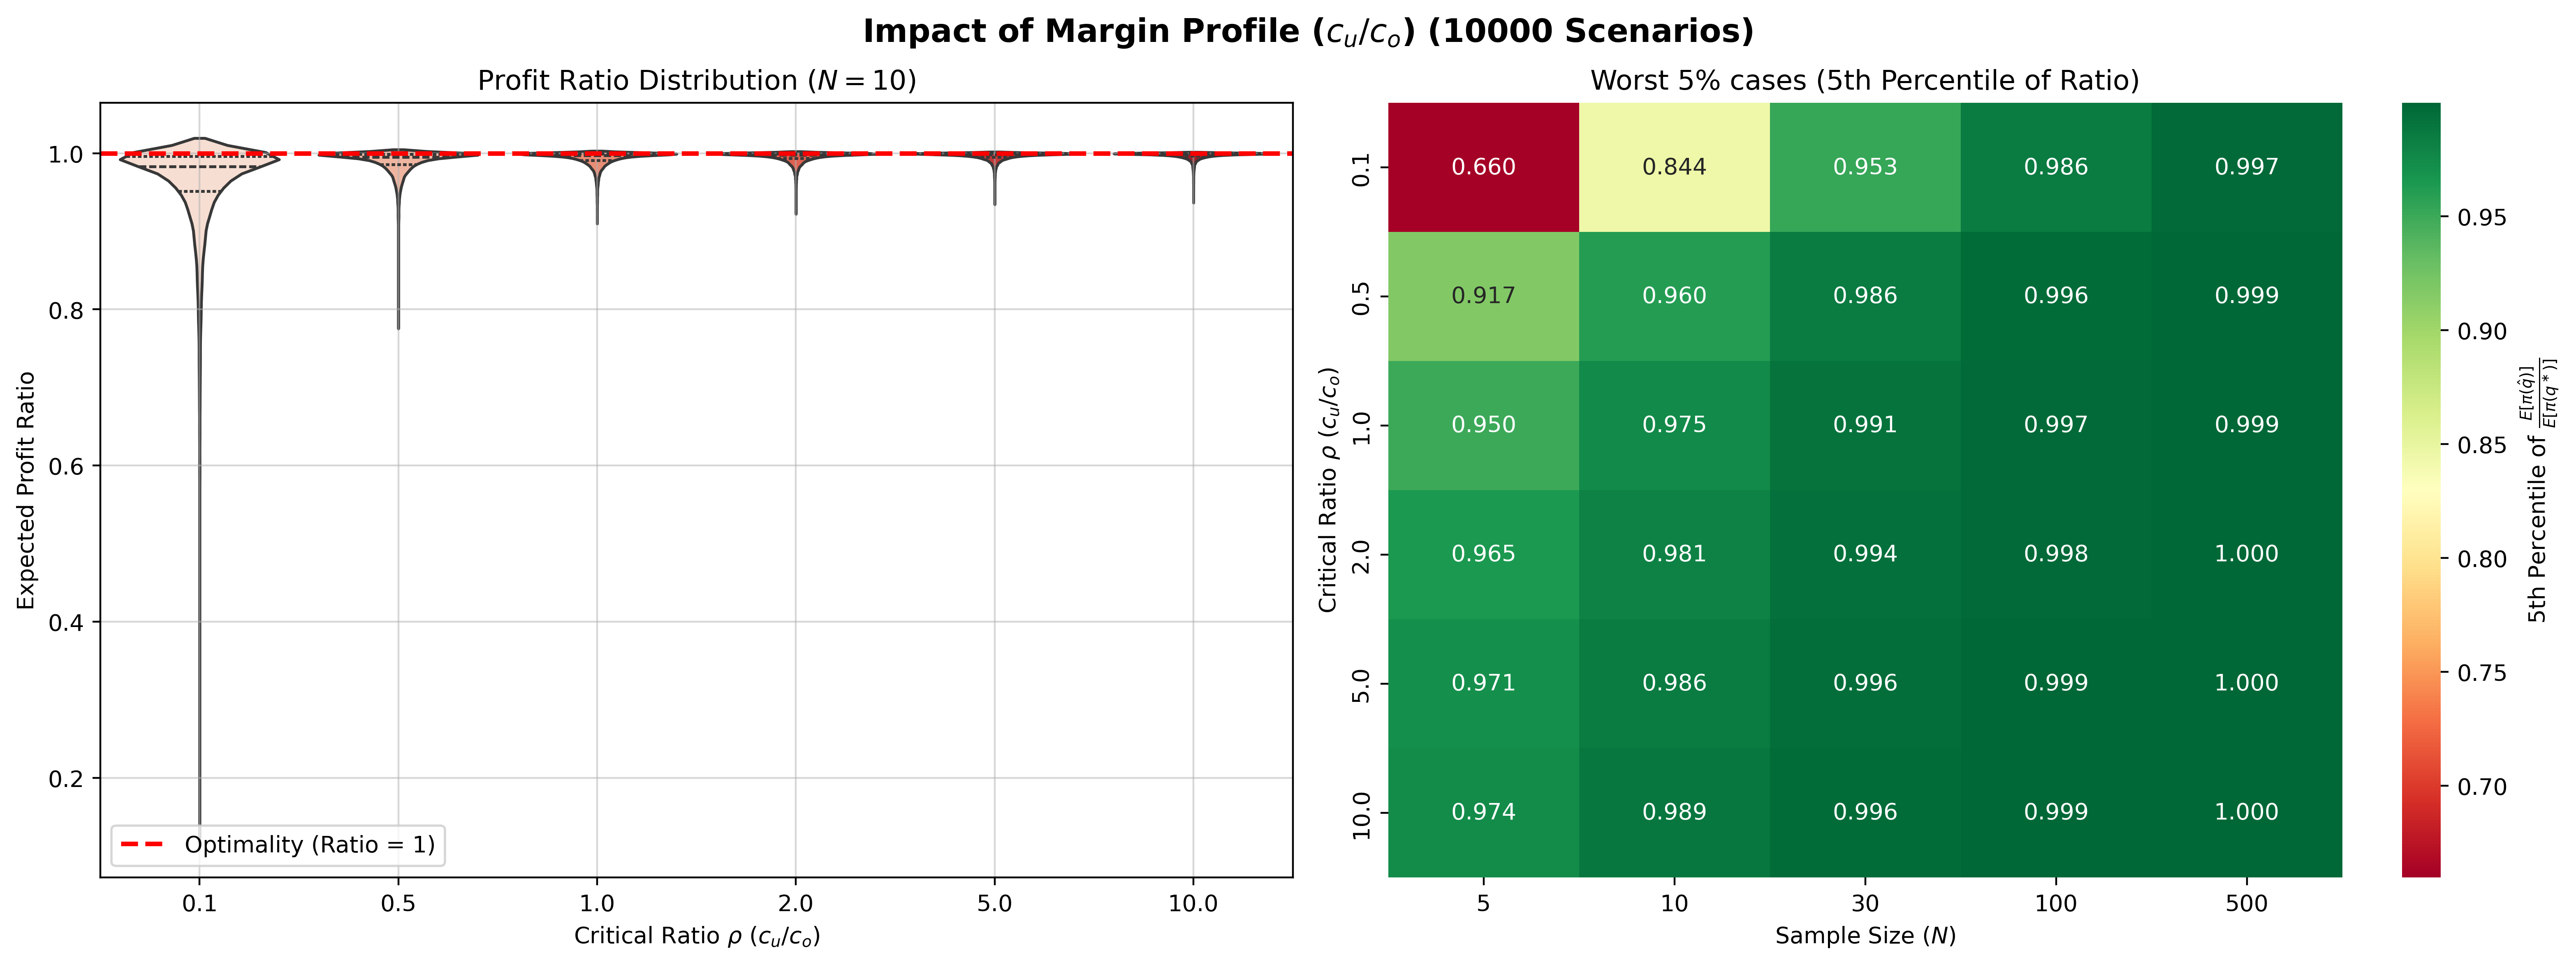


            Q3 - SUMMARY STATISTICS: Impact of Margin Profile (n=10)            
       mean    std  median   q2.5  q97.5  CI_95.0%_width
rho                                                     
0.1  0.9607 0.0609  0.9827 0.7918 1.0000          0.2082
0.5  0.9894 0.0148  0.9951 0.9492 1.0000          0.0508
1.0  0.9934 0.0091  0.9970 0.9669 1.0000          0.0331
2.0  0.9950 0.0070  0.9977 0.9754 1.0000          0.0246
5.0  0.9963 0.0055  0.9983 0.9810 1.0000          0.0190
10.0 0.9971 0.0045  0.9988 0.9843 1.0000          0.0157


In [158]:
# =============================================================================================
# Q3 - How the ratio c_u/c_o affects the ratio E[profit(q^, D)]/E[profit(q*, D)]     
# =============================================================================================

# define the range of critical ratios (rho = c_u / c_o)
rho_values = np.array([0.1, 0.5, 1.0, 2.0, 5.0, 10.0])

# fix the cost and salvage value from global economics
co_fixed = c - r 

# subset of sample sizes for the heatmap
n_samples_q3 = np.array([5, 10, 30, 100, 500])

# store results
q3_ratios = [] 
q3_risk_metrics = np.zeros((len(rho_values), len(n_samples_q3))) # matrix for the heatmap

for i, rho in enumerate(rho_values):
    # update economics dynamically based on the current rho target
    cu_current = rho * co_fixed
    p_current = cu_current + c  # varying price
    los_current = cu_current / (cu_current + co_fixed)
    
    # exact optimal values for this specific margin profile
    q_opt_current = compute_qopt(mu=mu_true, sigma=sigma_true, los=los_current)
    ep_opt_current = compute_ExpectedProfit(
        q=q_opt_current, mu=mu_true, sigma=sigma_true, c_u=cu_current, c_o=co_fixed
    )
    
    for j, n in enumerate(n_samples_q3):
        # generate scenarios
        mu_array_q3, sigma_array_q3 = generate_scenarios(
            n_sample=n, n_scenarios=n_scenarios, mu_true=mu_true, sigma_true=sigma_true, rng=rng
        )
        
        # sub-optimal quantities and expected profits
        q_hats_q3 = compute_qopt(mu=mu_array_q3, sigma=sigma_array_q3, los=los_current)
        ep_hats_q3 = compute_ExpectedProfit(
            q=q_hats_q3, mu=mu_true, sigma=sigma_true, c_u=cu_current, c_o=co_fixed
        )
        ep_ratios_q3 = compute_EPratio(E_profit=ep_opt_current, ep_hats=ep_hats_q3)
        
        # extract 5th percentile for the heatmap
        q3_risk_metrics[i, j] = np.percentile(ep_ratios_q3, 5)
        
        # stre full distribution data only for n=10 for violin plot
        if n == 10:
            for ratio in ep_ratios_q3:
                q3_ratios.append({
                    'rho_label': f"{rho:.1f}",
                    'Profit Ratio': ratio
                })

# convert to pandas df for easier Seaborn plotting
df_q3_ratios = pd.DataFrame(q3_ratios)

# === RESULTS

# PLOTS
fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=400)
fig.suptitle(f"Impact of Margin Profile ($c_u/c_o$) ({n_scenarios} Scenarios)", fontsize=14, y=0.97, fontweight="bold")

# Violin Plot showing the Tail Estimation Penalty (at n=10)
sns.violinplot(
    data=df_q3_ratios,
    x='rho_label',
    y='Profit Ratio',
    inner="quartile",
    ax=ax[0],
    palette="Reds",
    fill=True
)
ax[0].axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Optimality (Ratio = 1)')
ax[0].set_title(r"Profit Ratio Distribution ($N=10$)", fontsize=12)
ax[0].set_xlabel(r"Critical Ratio $\rho$ ($c_u/c_o$)")
ax[0].set_ylabel("Expected Profit Ratio")
ax[0].legend(loc="lower left")
ax[0].grid(True, alpha=0.5)

# Heatmap (5th Percentile)
sns.heatmap(
    q3_risk_metrics,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn", 
    xticklabels=n_samples_q3,
    yticklabels=[f"{r:.1f}" for r in rho_values],
    ax=ax[1],
    cbar_kws={'label': r'5th Percentile of $\frac{E[\pi(\hat{q})]}{E[\pi(q^\ast)]}$'}
)
ax[1].set_title("Worst 5% cases (5th Percentile of Ratio)", fontsize=12)
ax[1].set_xlabel("Sample Size ($N$)")
ax[1].set_ylabel(r"Critical Ratio $\rho$ ($c_u/c_o$)")

plt.tight_layout()
plt.show()

#save image in HIGH quality
fig.savefig("q3ViolinHeatPlots.pdf", bbox_inches="tight")

# === SUMMARY STATISTICS - Q3 (For n=10 Violin Plot)
print("\n" + "="*80)
print(f"{'Q3 - SUMMARY STATISTICS: Impact of Margin Profile (n=10)':^80}")
print("="*80)

summary_rows_q3 = []
for rho in rho_values:
    # Filter the DataFrame for the current rho
    subset = df_q3_ratios[df_q3_ratios['rho_label'] == f"{rho:.1f}"]['Profit Ratio']
    summary_rows_q3.append({
        "rho":            rho,
        "mean":           subset.mean(),
        "std":            subset.std(),
        "median":         subset.median(),
        "q2.5":           subset.quantile(0.025),
        "q97.5":          subset.quantile(0.975),
        "CI_95.0%_width": subset.quantile(0.975) - subset.quantile(0.025),
    })

df_summary_q3 = pd.DataFrame(summary_rows_q3).set_index("rho")
print(df_summary_q3.to_string(float_format="{:.4f}".format))

## Q4

/var/folders/48/rr_ylfv12t3fb01_brwwlvh00000gn/T/ipykernel_2439/2574349327.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


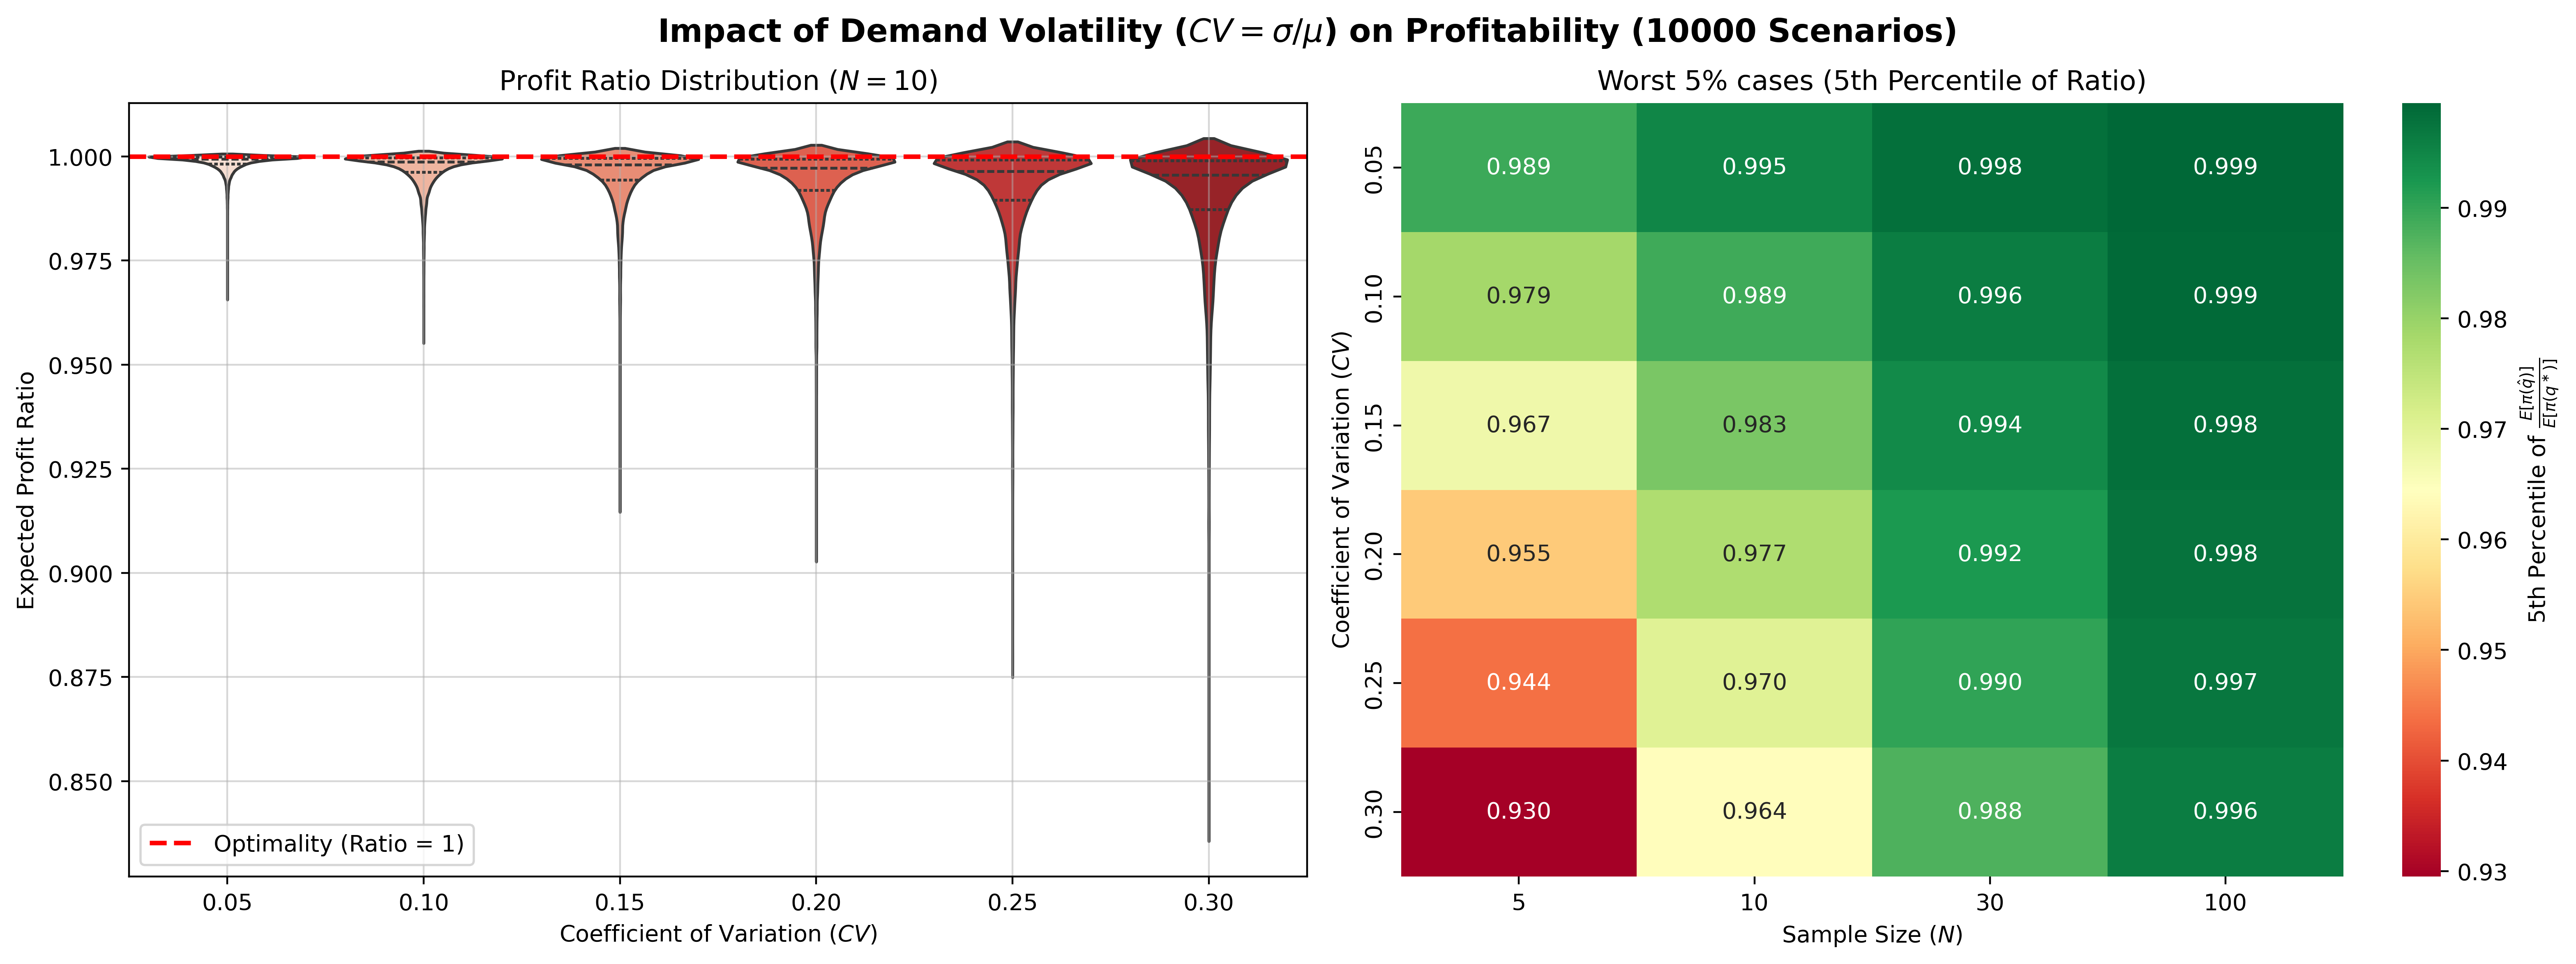


        Q4 - SUMMARY STATISTICS: Impact of Coefficient of Variation (CV)        
       mean    std  median   q2.5  q97.5  CI_95.0%_width
CV                                                      
0.05 0.9986 0.0019  0.9994 0.9933 1.0000          0.0067
0.10 0.9972 0.0040  0.9987 0.9858 1.0000          0.0142
0.15 0.9957 0.0062  0.9980 0.9780 1.0000          0.0220
0.20 0.9939 0.0086  0.9972 0.9699 1.0000          0.0301
0.25 0.9921 0.0111  0.9964 0.9619 1.0000          0.0381
0.30 0.9904 0.0136  0.9956 0.9519 1.0000          0.0481


In [159]:
# =============================================================================================
# Q4 - How the CV (sigma/mu) affects the ratio E[profit(q^, D)]/E[profit(q*, D)]     
# =============================================================================================

cv_values = np.array([0.05, 0.10, 0.15, 0.20, 0.25, 0.30]) # range of CVs
n_samples_q4 = np.array([5, 10, 30, 100]) 

# economics kept as the initial one
c_u_q4, c_o_q4, los_q4 = unit_costs(c=c, p=p, r=r)

# store results
q4_ratios = [] # For violin plot at n=10
q4_risk_matrix = np.zeros((len(cv_values), len(n_samples_q4))) # For heatmap

for i, cv in enumerate(cv_values):
    # compute std based on CV and fixed mu
    sigma_current = cv * mu_true
    
    # optimal values
    q_opt_current = compute_qopt(mu=mu_true, sigma=sigma_current, los=los_q4)
    ep_opt_current = compute_ExpectedProfit(
        q=q_opt_current, mu=mu_true, sigma=sigma_current, c_u=c_u_q4, c_o=c_o_q4
    )
    
    for j, n in enumerate(n_samples_q4):
        # generate scenarios
        mu_array_q4, sigma_array_q4 = generate_scenarios(
            n_sample=n, n_scenarios=n_scenarios, mu_true=mu_true, sigma_true=sigma_current, rng=rng
        )
        
        # q^ and EP[profit(q^, D)]
        q_hats_q4 = compute_qopt(mu=mu_array_q4, sigma=sigma_array_q4, los=los_q4)
        ep_hats_q4 = compute_ExpectedProfit(
            q=q_hats_q4, mu=mu_true, sigma=sigma_current, c_u=c_u_q4, c_o=c_o_q4
        )
        ep_ratios_q4 = compute_EPratio(E_profit=ep_opt_current, ep_hats=ep_hats_q4)
        
        # 5th percentile for the heatmap
        q4_risk_matrix[i, j] = np.percentile(ep_ratios_q4, 5)
        
        # store data only for n=10 for violin plot
        if n == 10:
            for ratio in ep_ratios_q4:
                q4_ratios.append({
                    'CV': f"{cv:.2f}",
                    'Profit Ratio': ratio
                })

df_q4_ratios = pd.DataFrame(q4_ratios)

# === RESULTS PLOTS
fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=400)
fig.suptitle(f"Impact of Demand Volatility ($CV = \sigma/\mu$) on Profitability ({n_scenarios} Scenarios)", fontsize=14, y=0.97, fontweight="bold")

# Plot 1: violin plot (at n=10)
sns.violinplot(
    data=df_q4_ratios, x='CV', y='Profit Ratio',
    inner="quartile", ax=ax[0], palette="Reds", fill=True
)
ax[0].axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Optimality (Ratio = 1)')
ax[0].set_title(r"Profit Ratio Distribution ($N=10$)", fontsize=12)
ax[0].set_xlabel(r"Coefficient of Variation ($CV$)")
ax[0].set_ylabel("Expected Profit Ratio")
ax[0].legend(loc="lower left")
ax[0].grid(True, alpha=0.5)

# Plot 2: heatmap
sns.heatmap(
    q4_risk_matrix, annot=True, fmt=".3f", cmap="RdYlGn", 
    xticklabels=n_samples_q4, yticklabels=[f"{cv:.2f}" for cv in cv_values],
    ax=ax[1], cbar_kws={'label': r'5th Percentile of $\frac{E[\pi(\hat{q})]}{E[\pi(q^\ast)]}$'}
)
ax[1].set_title("Worst 5% cases (5th Percentile of Ratio)", fontsize=12)
ax[1].set_xlabel("Sample Size ($N$)")
ax[1].set_ylabel(r"Coefficient of Variation ($CV$)")

plt.tight_layout()
plt.show()

#save image in HIGH quality
fig.savefig("q4ViolinHeatPlots.pdf", bbox_inches="tight")

# === SUMMARY STATISTICS - Q4
print("\n" + "="*80)
print(f"{'Q4 - SUMMARY STATISTICS: Impact of Coefficient of Variation (CV)':^80}")
print("="*80)

summary_rows_q4 = []
for cv in cv_values:
    subset = df_q4_ratios[df_q4_ratios['CV'] == f"{cv:.2f}"]['Profit Ratio']
    summary_rows_q4.append({
        "CV":             cv,
        "mean":           subset.mean(),
        "std":            subset.std(),
        "median":         subset.median(),
        "q2.5":           subset.quantile(0.025),
        "q97.5":          subset.quantile(0.975),
        "CI_95.0%_width": subset.quantile(0.975) - subset.quantile(0.025),
    })

df_summary_q4 = pd.DataFrame(summary_rows_q4).set_index("CV")
print(df_summary_q4.to_string(float_format="{:.4f}".format))